<a href="https://colab.research.google.com/github/maraymtaher/projet_IA/blob/main/Collect_Lait.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install folium matplotlib numpy pandas --quiet
print(' Bibliothèques installées')

✅ Bibliothèques installées


In [2]:
import json, math, random, numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

random.seed(42)
np.random.seed(42)

# Données intégrées directement
depot = {
    'id': 0, 'nom': 'Cooperative centrale',
    'lat': 12.100, 'lon': 15.050,
    'ouverture': 5.5, 'fermeture': 12.0,
    'volume': 0, 'duree_collecte': 0
}

CAPACITE_CAMION = 500
VITESSE_MOYENNE = 40

# Clusters / villages
clusters = [
    {'lat':12.28,'lon':15.02}, {'lat':12.35,'lon':15.18},
    {'lat':11.92,'lon':15.23}, {'lat':11.85,'lon':14.88},
    {'lat':12.45,'lon':14.82}, {'lat':12.15,'lon':14.72},
    {'lat':11.95,'lon':15.35}, {'lat':12.55,'lon':15.30},
    {'lat':12.22,'lon':15.42}, {'lat':11.78,'lon':15.10},
]
profils_tw = [
    {'ouverture':5.5,'fermeture':8.0}, {'ouverture':5.5,'fermeture':8.5},
    {'ouverture':6.0,'fermeture':8.0}, {'ouverture':6.0,'fermeture':8.5},
    {'ouverture':7.0,'fermeture':10.5},{'ouverture':7.5,'fermeture':10.5},
    {'ouverture':7.0,'fermeture':11.0},{'ouverture':6.0,'fermeture':11.0},
    {'ouverture':6.5,'fermeture':11.5},{'ouverture':5.5,'fermeture':11.5},
]
poids = [10,10,10,10,12,12,11,8,9,8]
prenoms = ['Tahir','Fatima','Wael','Amina','Youssef','Marayim','Saleh','Nafissa',
           'Mahamat','Zahra','Younouss','Khadija','Mustafa','Halima','Moussa',
           'Aisha','Ibrahim','Mariam','Hassan','Rahma','Oumar','Haoua','Ali',
           'Zeinab','Adoum','Achikou','Brahim','Djamila','Idriss','Fatime',
           'Noura','Abdelkader','Safia','Mahmoud','Hawa','Djimet','Nour',
           'Abderahim','Rakia','Mbairo','Sittou','Abba','Assita','Haroun',
           'Maimouna','Tahira','Bilal','Latifa','Souleyman','Hadja',
           'Farouk','Marieme','Cheikh','Aissatou','Mouhamad','Roukia',
           'Saad','Houleye','Modibo','Aicha','Babiker','Fanta',
           'Zakaria','Halimatou','Abdallah','Rokia','Boubacar','Aminata',
           'Ismail','Ramatou','Faisal','Kadidja','Musa','Safiatou',
           'Sadiq','Mariama','Umar','Bintou','Yahia','Coumba',
           'Ridwan','Dienaba','Anas','Oumou','Khalid','Kadja',
           'Hamid','Mbodj','Yacine','Astou','Tidiane','Ndéye',
           'Lamine','Khady','Seydou','Rokhaya','Malick','Gnagna','Ibou','Seynabou']
random.shuffle(prenoms)

eleveurs = []
id_c = 1
for cl in clusters:
    for _ in range(10):
        lat = round(cl['lat'] + np.random.uniform(-0.035,0.035), 4)
        lon = round(cl['lon'] + np.random.uniform(-0.035,0.035), 4)
        vol = int(np.clip(np.random.lognormal(3.6,0.55),15,160))
        duree = 0.17 if vol<30 else 0.25 if vol<55 else 0.33 if vol<90 else 0.42
        profil = random.choices(profils_tw, weights=poids, k=1)[0]
        nom = prenoms[id_c-1] if id_c<=len(prenoms) else f'E{id_c}'
        eleveurs.append({'id':id_c,'nom':nom,'lat':lat,'lon':lon,
                         'ouverture':profil['ouverture'],'fermeture':profil['fermeture'],
                         'volume':vol,'duree_collecte':duree})
        id_c+=1

print('='*50)
print(f'  Dépôt     : {depot["nom"]}')
print(f'  Éleveurs  : {len(eleveurs)}')
print(f'  Capacité  : {CAPACITE_CAMION} L/camion')
print(f'  Vitesse   : {VITESSE_MOYENNE} km/h')
print('='*50)

  Dépôt     : Cooperative centrale
  Éleveurs  : 100
  Capacité  : 500 L/camion
  Vitesse   : 40 km/h


In [3]:
df = pd.DataFrame(eleveurs)
print('Aperçu des 5 premiers éleveurs :')
print(df[['id','nom','lat','lon','ouverture','fermeture','volume']].head())
print()
print('Statistiques des volumes (L) :')
print(df['volume'].describe().round(1))
print()
# Répartition des profils
tot = df[df['fermeture']<=8.5]
inter = df[(df['fermeture']>8.5)&(df['fermeture']<=11.0)]
flex = df[df['fermeture']>11.0]
print(f'Profil tôt        : {len(tot)} éleveurs (fermeture ≤ 8h30)')
print(f'Profil interméd.  : {len(inter)} éleveurs')
print(f'Profil flexible   : {len(flex)} éleveurs (fermeture > 11h)')
print(f'Volume total prévu: {df["volume"].sum()} L  →  {df["volume"].sum()//CAPACITE_CAMION + (1 if df["volume"].sum()%CAPACITE_CAMION else 0)} tournées nécessaires')

Aperçu des 5 premiers éleveurs :
   id     nom      lat      lon  ouverture  fermeture  volume
0   1  Assita  12.2712  15.0516        6.0        8.0      52
1   2    Abba  12.2559  14.9959        5.5       11.5      84
2   3   Ndéye  12.2491  15.0456        6.5       11.5      87
3   4   Zahra  12.2464  15.0529        6.0        8.5      55
4   5   Rokia  12.3033  14.9999        7.0       11.0      28

Statistiques des volumes (L) :
count    100.0
mean      44.0
std       21.1
min       15.0
25%       28.0
50%       42.0
75%       54.2
max      122.0
Name: volume, dtype: float64

Profil tôt        : 43 éleveurs (fermeture ≤ 8h30)
Profil interméd.  : 36 éleveurs
Profil flexible   : 21 éleveurs (fermeture > 11h)
Volume total prévu: 4402 L  →  9 tournées nécessaires


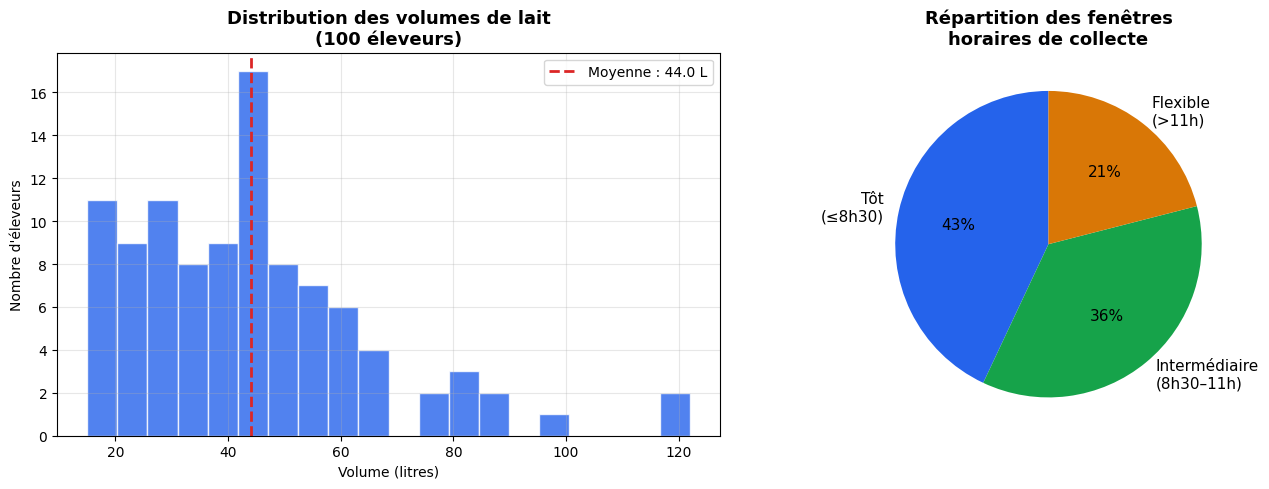

✅ Graphique 1 sauvegardé


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogramme des volumes
vols = [e['volume'] for e in eleveurs]
axes[0].hist(vols, bins=20, color='#2563eb', alpha=0.8, edgecolor='white')
axes[0].axvline(np.mean(vols), color='#dc2626', linestyle='--', linewidth=2,
                label=f'Moyenne : {np.mean(vols):.1f} L')
axes[0].set_title('Distribution des volumes de lait\n(100 éleveurs)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Volume (litres)')
axes[0].set_ylabel('Nombre d\'éleveurs')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Répartition des fenêtres temporelles
labels = ['Tôt\n(≤8h30)', 'Intermédiaire\n(8h30–11h)', 'Flexible\n(>11h)']
sizes  = [len(tot), len(inter), len(flex)]
colors = ['#2563eb', '#16a34a', '#d97706']
axes[1].pie(sizes, labels=labels, colors=colors, autopct='%1.0f%%',
            startangle=90, textprops={'fontsize':11})
axes[1].set_title('Répartition des fenêtres\nhoraires de collecte', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('graphique1_volumes.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Graphique 1 sauvegardé')

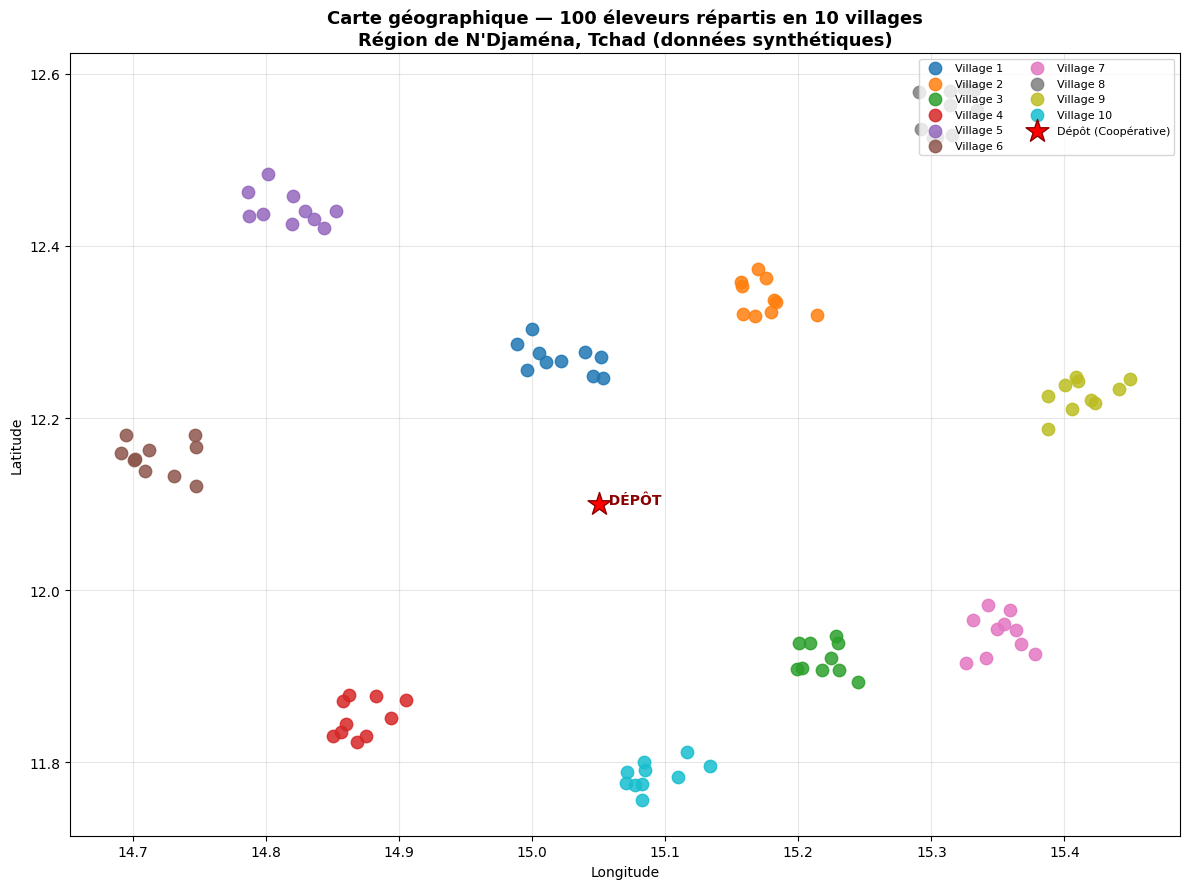

✅ Graphique 2 sauvegardé


In [5]:
fig, ax = plt.subplots(figsize=(12, 9))

couleurs_clusters = plt.cm.tab10.colors

# Tracer chaque cluster
for ci in range(10):
    debut = ci*10; fin = debut+10
    grp = eleveurs[debut:fin]
    lats = [e['lat'] for e in grp]
    lons = [e['lon'] for e in grp]
    ax.scatter(lons, lats, c=[couleurs_clusters[ci]], s=80,
               alpha=0.85, zorder=3, label=f'Village {ci+1}')

# Dépôt
ax.scatter(depot['lon'], depot['lat'], c='red', s=300,
           marker='*', zorder=5, label='Dépôt (Coopérative)', edgecolors='darkred')
ax.annotate('  DÉPÔT', (depot['lon'], depot['lat']),
            fontsize=10, fontweight='bold', color='darkred')

ax.set_title('Carte géographique — 100 éleveurs répartis en 10 villages\n'
             'Région de N\'Djaména, Tchad (données synthétiques)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.legend(loc='upper right', fontsize=8, ncol=2)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('graphique2_carte.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Graphique 2 sauvegardé')

In [6]:
#  Fonctions de l'algorithme génétique

def haversine(p1, p2):
    R = 6371
    lat1,lat2 = math.radians(p1['lat']),math.radians(p2['lat'])
    lon1,lon2 = math.radians(p1['lon']),math.radians(p2['lon'])
    dlat,dlon = lat2-lat1, lon2-lon1
    a = math.sin(dlat/2)**2 + math.cos(lat1)*math.cos(lat2)*math.sin(dlon/2)**2
    return round(6371*2*math.asin(math.sqrt(a)),2)

def construire_matrice():
    tous = [depot]+eleveurs; N = len(tous)
    M = [[0.0]*N for _ in range(N)]
    for i in range(N):
        for j in range(N):
            if i!=j: M[i][j]=haversine(tous[i],tous[j])
    return M

def calculer_volumes():
    for e in eleveurs:
        base=e['volume']; jours=np.arange(90)
        vols=base+jours*0.05+base*0.1*np.sin(2*np.pi*jours/30)+np.random.normal(0,base*0.15,90)
        e['volume_prevu']=round(float(np.mean(np.maximum(vols,5)[-7:])),1)

def decouper_tournees(itin):
    tournees,cur,vol=[],[],0
    for id_e in itin:
        e=eleveurs[id_e-1]; v=e.get('volume_prevu',e['volume'])
        if vol+v>CAPACITE_CAMION and cur:
            tournees.append(cur); cur=[]; vol=0
        cur.append(id_e); vol+=v
    if cur: tournees.append(cur)
    return tournees

def evaluer(itin, M):
    tournees=decouper_tournees(itin)
    cout=dist=pen=0
    for t in tournees:
        h=depot['ouverture']; d=0; p=0; pos=0
        for id_e in t:
            e=eleveurs[id_e-1]
            dd=M[pos][id_e]; d+=dd
            arr=h+dd/VITESSE_MOYENNE
            if arr<e['ouverture']: arr=e['ouverture']
            elif arr>e['fermeture']: p+=(arr-e['fermeture'])*500
            h=arr+e['duree_collecte']; pos=id_e
        dr=M[pos][0]; d+=dr; hr=h+dr/VITESSE_MOYENNE
        if hr>depot['fermeture']: p+=(hr-depot['fermeture'])*500
        cout+=d+p; dist+=d; pen+=p
    return cout, dist, pen

def creer_itin():
    ids=[e['id'] for e in eleveurs]; random.shuffle(ids); return ids

def tournoi(pop, M):
    cands=random.sample(pop,5)
    cands.sort(key=lambda x:evaluer(x,M)[0]); return cands[0]

def pmx(a,b):
    n=len(a); p1=random.randint(0,n-2); p2=random.randint(p1+1,n-1)
    enfant=[None]*n; enfant[p1:p2+1]=a[p1:p2+1]
    for g in b:
        if g not in enfant:
            for i in range(n):
                if enfant[i] is None: enfant[i]=g; break
    return enfant

def mutation(itin):
    if random.random()<0.3:
        i,j=random.sample(range(len(itin)),2)
        itin[i],itin[j]=itin[j],itin[i]
    return itin

# Préparer
calculer_volumes()
M = construire_matrice()
print(f' Matrice {len(M)}×{len(M)} construite ({len(M)**2} distances calculées)')
print(f'   Volume total prévu : {sum(e["volume_prevu"] for e in eleveurs):.1f} L')

✅ Matrice 101×101 construite (10201 distances calculées)
   Volume total prévu : 4526.7 L


In [7]:
TAILLE_POP = 80
NB_GEN     = 150

population    = [creer_itin() for _ in range(TAILLE_POP)]
meilleur      = None
meilleur_cout = float('inf')
historique_cout = []

print('Lancement de l\'algorithme génétique...')
print(f'Population : {TAILLE_POP} | Générations : {NB_GEN}')
print('-'*45)

for gen in range(NB_GEN):
    scores = [(evaluer(i,M)[0], i) for i in population]
    scores.sort(key=lambda x:x[0])
    if scores[0][0] < meilleur_cout:
        meilleur_cout = scores[0][0]
        meilleur = scores[0][1][:]
    historique_cout.append(meilleur_cout)
    if gen % 25 == 0:
        print(f'  Génération {gen:>3} | Meilleur coût : {meilleur_cout:>10.1f}')
    nv = [i for _,i in scores[:8]]
    while len(nv) < TAILLE_POP:
        nv.append(mutation(pmx(tournoi(population,M), tournoi(population,M))))
    population = nv

print('-'*45)
print(f' Terminé ! Meilleur coût final : {meilleur_cout:.1f}')

Lancement de l'algorithme génétique...
Population : 80 | Générations : 150
---------------------------------------------
  Génération   0 | Meilleur coût :   215564.7
  Génération  25 | Meilleur coût :   120991.8
  Génération  50 | Meilleur coût :   100357.8
  Génération  75 | Meilleur coût :    71752.2
  Génération 100 | Meilleur coût :    57219.3
  Génération 125 | Meilleur coût :    46849.0
---------------------------------------------
✅ Terminé ! Meilleur coût final : 40890.9


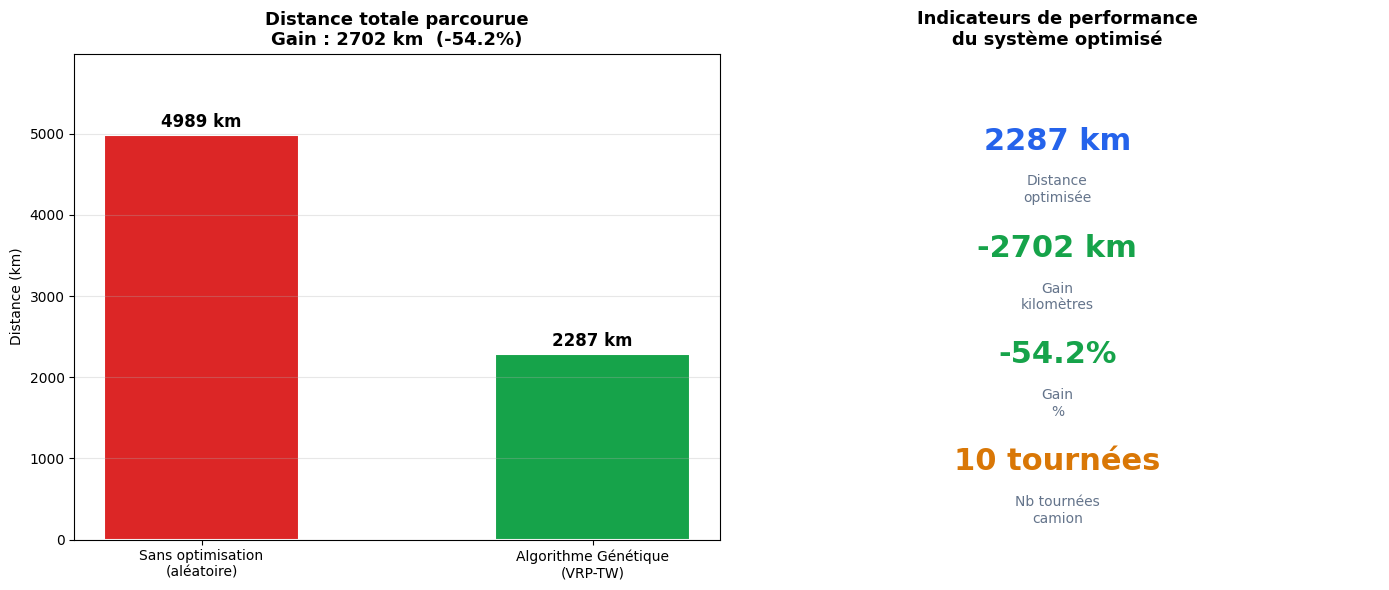

 Graphique 4 sauvegardé


In [8]:
# Distance sans optimisation de moyenne sur 5 itinéraires aléatoires
dists_aleat = []
for _ in range(5):
    r = creer_itin()
    _, d, _ = evaluer(r, M)
    dists_aleat.append(d)
dist_aleat_moy = round(sum(dists_aleat)/len(dists_aleat), 2)

_, dist_opt, pen_opt = evaluer(meilleur, M)
dist_opt = round(dist_opt, 2)
gain_km   = round(dist_aleat_moy - dist_opt, 2)
gain_pct  = round(gain_km / dist_aleat_moy * 100, 1)
nb_tournees = len(decouper_tournees(meilleur))

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Barres comparaison
methodes = ['Sans optimisation\n(aléatoire)', 'Algorithme Génétique\n(VRP-TW)']
distances = [dist_aleat_moy, dist_opt]
couleurs  = ['#dc2626', '#16a34a']
bars = axes[0].bar(methodes, distances, color=couleurs, width=0.5,
                   edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, distances):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+50,
                 f'{val:.0f} km', ha='center', va='bottom',
                 fontweight='bold', fontsize=12)
axes[0].set_title(f'Distance totale parcourue\nGain : {gain_km:.0f} km  (-{gain_pct}%)',
                  fontsize=13, fontweight='bold')
axes[0].set_ylabel('Distance (km)')
axes[0].grid(True, alpha=0.3, axis='y')
axes[0].set_ylim(0, dist_aleat_moy * 1.2)

# Indicateurs clés
indicateurs = ['Distance\noptimisée', 'Gain\nkilomètres', 'Gain\n%', 'Nb tournées\ncamion']
valeurs     = [f'{dist_opt:.0f} km', f'-{gain_km:.0f} km', f'-{gain_pct}%', f'{nb_tournees} tournées']
couleurs2   = ['#2563eb','#16a34a','#16a34a','#d97706']
for i, (ind, val, col) in enumerate(zip(indicateurs, valeurs, couleurs2)):
    axes[1].text(0.5, 0.82-i*0.22, val, ha='center', va='center',
                 fontsize=22, fontweight='bold', color=col,
                 transform=axes[1].transAxes)
    axes[1].text(0.5, 0.72-i*0.22, ind, ha='center', va='center',
                 fontsize=10, color='#64748b',
                 transform=axes[1].transAxes)
axes[1].set_title('Indicateurs de performance\ndu système optimisé',
                  fontsize=13, fontweight='bold')
axes[1].axis('off')

plt.tight_layout()
plt.savefig('graphique.png', dpi=150, bbox_inches='tight')
plt.show()
print(f' Graphique 4 sauvegardé')